# Impatto dell'intervallo di sanificazione

Valuta la sensibilità della politica dinamica `c_wall` all'intervallo di sanificazione periodica dei nodi (`SANITIZE_INTERVAL_SECONDS`). Configurazione del cluster, workload e grado di conflitto sono fissi in tutti gli scenari: l'unica variabile indipendente è l'intervallo.

**Ipotesi.** Curva a U per la latenza di scheduling. A intervalli brevi i nodi escono spesso da $\mathcal{N}$ e restano indisponibili in attesa del completamento dei task attivi (la sanificazione attende il drain prima di ripulire); a intervalli lunghi le tracce contestuali non vengono ripulite abbastanza in fretta e i task in conflitto restano bloccati. Esiste quindi un intervallo intermedio che minimizza la latenza.

**Nota trasversale su tutte le figure.** La banda attorno alle curve è media ± 1 deviazione standard *tra le repliche*: misura la ripetibilità dell'esperimento, non la dispersione dei singoli task. Agli intervalli grandi (30–45s) la banda si allarga perché in una run di ~120s entrano pochi cicli di sanificazione, e la metrica dipende molto da *quando* cadono quei pochi tick rispetto ai task in esecuzione: la stima è dominata dalla varianza. L'effetto è coerente in tutte le metriche legate alla sanificazione.

## Configurazione

In [2036]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "analysis")
import analysis.utils as utils

RESULTS_ROOT = Path("results")
SCENARIOS_ROOT = Path("scenarios")
FIG_DIR = Path("analysis/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR = Path("analysis/tables")
TAB_DIR.mkdir(parents=True, exist_ok=True)

INTERVALS = [1, 2, 3, 5, 10, 20, 30, 40, 50, 60]
SCENARIOS = [f"sanitize-{i}" for i in INTERVALS]
POINT_KEY = "sanitize_interval_seconds"

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "savefig.bbox": "tight",
    }
)

In [2037]:
def band_plot(ax, stats, color, label=None, scale=1.0, marker="o"):
    x = stats.index.to_numpy()
    m = stats["mean"].to_numpy() * scale
    s = stats["std"].fillna(0).to_numpy() * scale
    ax.plot(x, m, marker=marker, color=color, label=label)
    ax.fill_between(x, m - s, m + s, color=color, alpha=0.18, linewidth=0)


def set_log_x(ax):
    ax.set_xscale("log")
    ax.set_xticks(INTERVALS)
    ax.set_xticklabels(INTERVALS)
    ax.set_xlabel("Intervallo di sanificazione (s)")


## Caricamento dei dati

In [2038]:
tasks, nodes, runs = utils.load_scenarios(RESULTS_ROOT, SCENARIOS, POINT_KEY)
scenario_to_dir = {s: SCENARIOS_ROOT / s for s in SCENARIOS}

print(
    f"task totali: {len(tasks)}  |  run: {runs['replica'].count()}  "
    f"|  intervalli: {sorted(tasks['point'].unique())}"
)
runs.groupby("point")["replica"].nunique().rename("repliche")

task totali: 10000  |  run: 50  |  intervalli: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60)]


point
1     5
2     5
3     3
5     5
10    5
20    5
30    5
40    4
50    5
60    5
Name: repliche, dtype: int64

## 0. Controlli di sanità

**Cosa si verifica.** Che ogni scenario abbia il numero atteso di repliche; che tutti i task siano stati ammessi (nessuna TaskRequest rifiutata da Gatekeeper); che nessuna run sia andata in timeout; che non esistano rifiuti di scheduling per cause diverse da `c_wall`/taint (`rifiuti_other` deve essere 0); e che la durata di esecuzione mediana sia coerente con la durata simulata dei task.

**Perché conta.** Autorizza a fidarsi del resto: se una run ha task non ammessi, in timeout o rifiutati per cause anomale, i suoi numeri non sono confrontabili con gli altri scenari.

In [2039]:
checks = []
for point, g in tasks.groupby("point"):
    checks.append(
        {
            "intervallo": point,
            "repliche": g["replica"].nunique(),
            "task": len(g),
            "ammessi_ok": bool(g["admitted"].sum() == len(g)),
            "rifiuti_other": int(g["n_attempts_other"].sum()),
            "timeout": int(g["timed_out"].sum()),
            "execution_mediana": round(g["execution_s"].median(), 2),
        }
    )
display(pd.DataFrame(checks).set_index("intervallo"))


,repliche,task,ammessi_ok,rifiuti_other,timeout,execution_mediana
intervallo,,,,,,
1,5,1000,True,0,0,21.27
2,5,1000,True,0,0,21.27
3,3,1000,True,0,0,21.27
5,5,1000,True,0,0,21.26
10,5,1000,True,0,0,21.29
20,5,1000,True,0,0,21.30
30,5,1000,True,0,0,21.27
40,4,1000,True,0,0,21.28
50,5,1000,True,0,0,21.27


## 1. Parametri dell'esperimento

Riepilogo dei parametri fissi (identici in tutti gli scenari, per isolare l'effetto del solo intervallo) e della griglia della variabile indipendente. Esportato in LaTeX. La durata dei task (10s) fissa la posizione attesa del braccio sinistro della U: sotto quella soglia l'intervallo diventa più corto del tempo di drain dei nodi.

In [2040]:
r0 = runs.iloc[0]
params = pd.DataFrame(
    {
        "Parametro": [
            "Contesti $K$",
            "Densità di conflitto $\\rho$",
            "Task per run $N$",
            "Rate di sottomissione",
            "Durata task",
            "Nodi worker",
            "Repliche",
            "Intervalli valutati",
        ],
        "Valore": [
            int(tasks["context"].str.extract(r"(\d+)").astype(int).max().iloc[0]),
            r0["conflict_density"],
            int(r0["tasks"]),
            f"1 ogni {r0['rate_seconds']:g}s",
            f"{r0['task_duration_seconds']:g}s",
            nodes["node"].nunique(),
            int(runs.groupby("point")["replica"].nunique().max()),
            ", ".join(f"{i}s" for i in INTERVALS),
        ],
    }
).set_index("Parametro")
display(params)
params.to_latex(TAB_DIR / "sanitize_parametri.tex", escape=False)

,Valore
Parametro,
Contesti $K$,10
Densità di conflitto $\rho$,0.5
Task per run $N$,200
Rate di sottomissione,1 ogni 1s
Durata task,20s
Nodi worker,5
Repliche,5
Intervalli valutati,"1s, 2s, 3s, 5s, 10s, 20s, 30s, 40s, 50s, 60s"


## 2. Curva principale: latenza di scheduling

**Cosa si valuta.** La latenza di scheduling per task (dalla sottomissione al binding del pod), media tra repliche, in funzione dell'intervallo. È la metrica principale e la misura "per-task": quanto attende il singolo task.

**Cosa dice il grafico.** La U attesa: minimo intorno a 5–10s, risalita a sinistra (nodi troppo spesso indisponibili perché continuamente in sanificazione) e risalita marcata a destra (tracce ripulite troppo di rado, task in conflitto bloccati più a lungo). Il minimo individua l'intervallo operativo che minimizza la latenza.

La media è tirata verso l'alto dalla coda dei task bloccati: la distribuzione è bimodale (task veloci non bloccati contro task in lunga attesa). La forma completa di questa distribuzione è nella CDF della sezione 5.

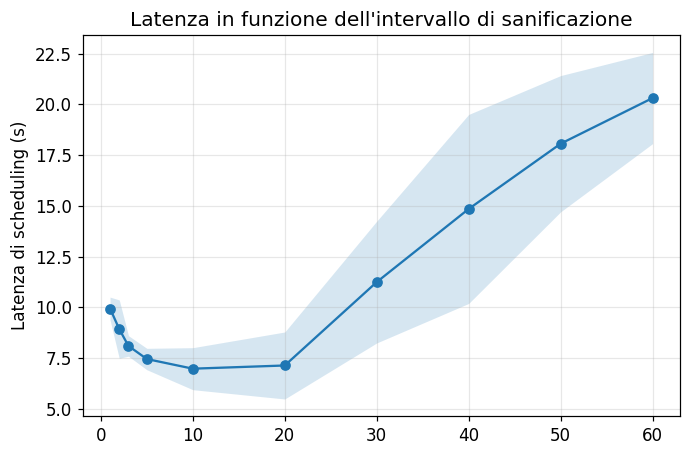

Minimo della latenza media all'intervallo = 10s (6.980s)


In [2041]:
lat = utils.per_point_stat(tasks, "latency_s", "mean")
med = utils.per_point_stat(tasks, "latency_s", "median")
p95 = utils.per_point_stat(tasks, "latency_s", lambda s: np.percentile(s, 95))

fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, lat, "#1f77b4")
# set_log_x(ax)
ax.set_ylabel("Latenza di scheduling (s)")
ax.set_title("Latenza in funzione dell'intervallo di sanificazione")
fig.savefig(FIG_DIR / "sanitize_latenza.pdf")
plt.show()

opt = lat["mean"].idxmin()
print(f"Minimo della latenza media all'intervallo = {opt}s ({lat['mean'].min():.3f}s)")


## 3. Perché la U ha quella forma

Due letture spiegano il meccanismo dietro la curva.

**Ripartizione per causa di blocco.** Ogni task bloccato è classificato per causa: `taint` (nodo fuori da $\mathcal{N}$, in sanificazione), `wall` (tracce contestuali in conflitto), `mixed` (entrambe durante l'attesa), `none` (mai bloccato). A intervalli brevi domina `taint` (i nodi passano molto tempo in sanificazione), che si assottiglia verso il minimo della U; a intervalli lunghi cresce la componente da tracce (`mixed`). Il minimo di blocco per taint coincide col minimo della latenza: conferma diretta dell'ipotesi. Le barre sommano a 1 per costruzione.

**Attesa dei task bloccati.** Tempo medio che un task bloccato attende prima di essere schedulato. Cresce con l'intervallo perché lo sblocco avviene solo al successivo ciclo di sanificazione del nodo. È la quantità $E[t_{wait}]$ che, con la probabilità di blocco, determina la latenza media.

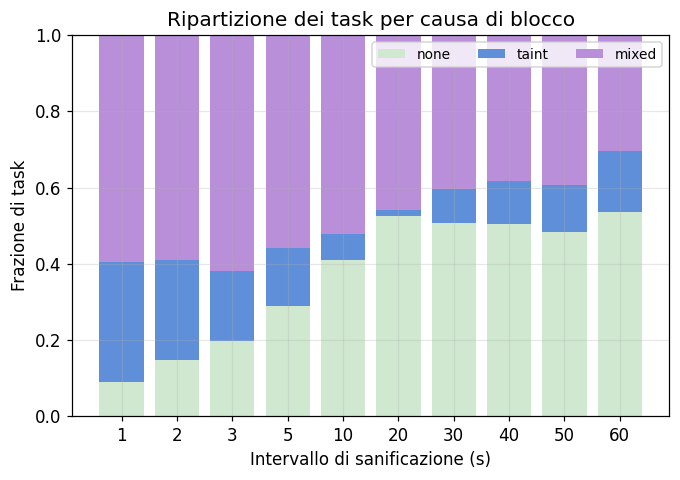

In [2042]:
frac = utils.block_fraction_by_cause(tasks)
order = [c for c in ["none", "wall", "taint", "mixed", "other"] if c in frac.columns]
frac = frac[order]
colori = {"none": "#cfe8cf", "wall": "#d95f5f", "taint": "#5f8fd9", "mixed": "#b98fd9", "other": "#999999"}
x = np.arange(len(frac))
bottom = np.zeros(len(frac))
fig, ax = plt.subplots(figsize=(7, 4.5))
for c in order:
    ax.bar(x, frac[c].values, bottom=bottom, label=c, color=colori.get(c))
    bottom += frac[c].values
ax.set_xticks(x)
ax.set_xticklabels(frac.index)
ax.set_ylim(0, 1)
ax.set_xlabel("Intervallo di sanificazione (s)")
ax.set_ylabel("Frazione di task")
ax.set_title("Ripartizione dei task per causa di blocco")
ax.legend(ncol=len(order), fontsize=9, loc="upper right")
fig.savefig(FIG_DIR / "sanitize_cause_blocco.pdf")
plt.show()


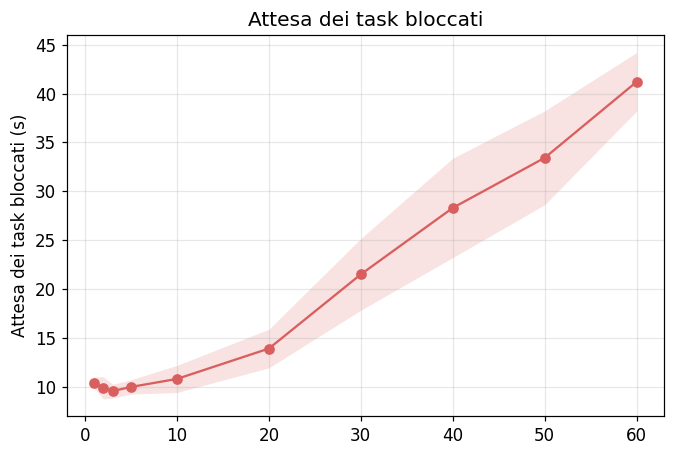

In [2043]:
wait = utils.per_point_stat(tasks[tasks["blocked"]], "wait_s", "mean")
fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, wait, "#d95f5f")
# set_log_x(ax)
ax.set_ylabel("Attesa dei task bloccati (s)")
ax.set_title("Attesa dei task bloccati")
fig.savefig(FIG_DIR / "sanitize_attesa.pdf")
plt.show()


## 4. Disponibilità dei nodi

**Cosa si valuta.** Frazione di tempo in cui i nodi worker sono fuori da $\mathcal{N}$ (taint di sanificazione attivo), integrata sull'intera durata della run e mediata su nodi e repliche. È la controparte del fenomeno vista dal lato cluster, non dal lato task.

**Cosa dice il grafico.** Andamento decrescente: più corto l'intervallo, più spesso i nodi entrano in sanificazione e vi restano finché i task attivi non completano, quindi maggiore l'indisponibilità. Spiega il braccio sinistro della U dal punto di vista dell'infrastruttura: a intervalli brevi i task non trovano nodi disponibili non per le tracce, ma perché i nodi sono continuamente in pulizia.

**Non-monotonia a 30–45s.** Il valore a 30s risulta più alto che a 45s. Non è un fatto da giustificare come reale: è dominato dalla varianza. Con run di ~120s, a 45s entrano solo ~2 cicli di sanificazione, e la frazione di indisponibilità dipende fortemente da *quando* quei pochi tick cadono rispetto ai task in esecuzione; con così pochi campioni per run la media è instabile. La banda a 45s (da ~28% a ~53%) copre ampiamente il valore a 30s: le due misure sono statisticamente compatibili e l'inversione non è significativa. Stesso effetto "pochi tick per run" visibile nell'instabilità di latenza e attesa agli stessi intervalli.

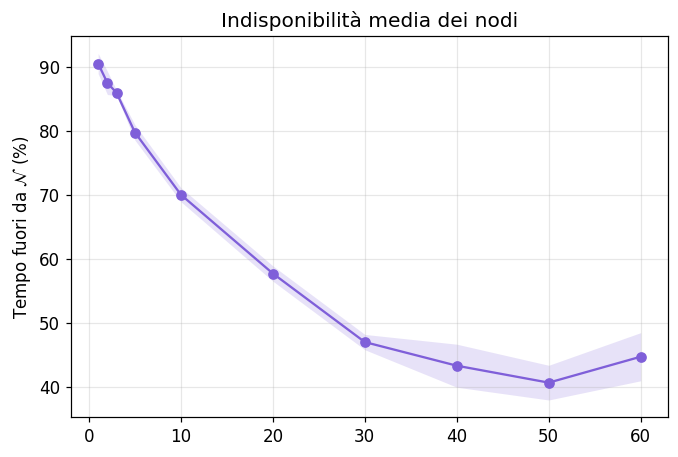

In [2044]:
unavail = utils.node_unavailability(nodes, runs)
fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, unavail, "#7f5fd9", scale=100)
# set_log_x(ax)
ax.set_ylabel(r"Tempo fuori da $\mathcal{N}$ (%)")
ax.set_title("Indisponibilità media dei nodi")
fig.savefig(FIG_DIR / "sanitize_disponibilita.pdf")
plt.show()


## 5. Distribuzione cumulata della latenza

**Come si legge.** Per ogni valore $x$ sull'asse orizzontale (una latenza), la curva dà la frazione di task schedulati entro quel tempo. Esempio: se a $x=5$s la curva vale 0.8, l'80% dei task è stato schedulato entro 5 secondi. Ogni curva è un intervallo; confrontarle mostra come cambia l'intera distribuzione delle latenze, non solo la media.

**Cosa indica ogni curva.** Tre elementi su ciascuna:
- *altezza vicino all'origine* (gradino verticale iniziale): frazione di task **non bloccati**, schedulati subito. A intervallo breve sale quasi verticale fino a valori alti; a intervallo lungo parte più in basso;
- *coda a destra*: popolazione dei task **bloccati**; quanto la curva si allunga prima di 1.0 misura le latenze peggiori. A 45s striscia oltre 100s, a 1s raggiunge 1.0 in pochi secondi;
- *pendenza*: ripida = latenze concentrate, distesa = latenze sparse.

**Cosa dice il grafico.** Al crescere dell'intervallo il gradino iniziale si abbassa e la coda si allunga: cresce sia la frazione di task bloccati sia il tempo d'attesa. È la giustificazione visiva della bimodalità: le due popolazioni appaiono come gradino più coda, e la coda si ingrossa con l'intervallo.

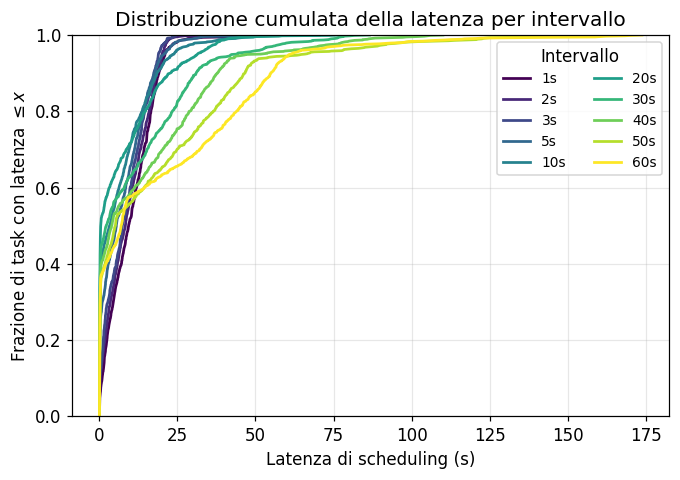

In [2045]:
cmap = plt.get_cmap("viridis")
fig, ax = plt.subplots(figsize=(7, 4.5))
for k, point in enumerate(INTERVALS):
    x, y = utils.ecdf(tasks[tasks["point"] == point]["latency_s"])
    ax.plot(x, y, ls="-", lw=1.8, color=cmap(k / max(1, len(INTERVALS) - 1)), label=f"{point}s")
ax.set_xlabel("Latenza di scheduling (s)")
ax.set_ylabel(r"Frazione di task con latenza $\leq x$")
ax.set_ylim(0, 1)
ax.set_title("Distribuzione cumulata della latenza per intervallo")
ax.legend(title="Intervallo", ncol=2, fontsize=9)
fig.savefig(FIG_DIR / "sanitize_cdf.pdf")
plt.show()


## 6. Makespan

**Cosa si valuta.** Il makespan è il tempo dal primo task sottomesso all'ultimo completato: quanto impiega l'intero lotto a smaltirsi. Un solo numero per run (media tra repliche), non una media di valori per-task.

**Per-task vs per-batch.** Latenza (sez. 2) e makespan misurano cose diverse e complementari:
- la *latenza* è per-task, il costo dal punto di vista del singolo task ("quanto aspetto io");
- il *makespan* è per-batch, il costo di sistema ("quanto ci mette tutto il carico a finire").

Due conseguenze. Primo, il makespan **contiene per costruzione la durata della sottomissione**: 100 task a 1/s richiedono già 100s solo per essere spediti, quindi il makespan parte da lì e vi aggiunge la coda finale. È il motivo per cui i suoi valori stanno sui 115–140s mentre la latenza per-task sta sui 2–17s. Secondo, le attese dei task bloccati **si sovrappongono nel tempo**: se molti task attendono in parallelo, la latenza media sale molto ma il makespan cresce poco, perché quelle attese sono concorrenti. Il makespan quindi *ridimensiona* l'impatto: il singolo task può attendere ~17s, ma il batch nel complesso rallenta solo di ~20s su ~120. Mostrarlo accanto alla latenza evita di sovrastimare l'effetto della sanificazione.

**Cosa dice il grafico.** La U è molto più schiacciata che nella latenza per-task, perché dominata dalla componente costante di sottomissione e dalla parallelizzazione delle attese. La banda si allarga a destra per lo stesso effetto pochi-tick-per-run.

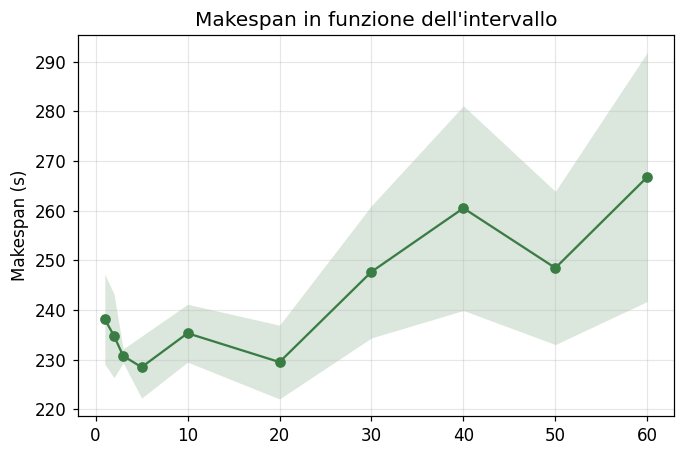

In [2046]:
mk = runs.groupby("point")["makespan_s"].agg(["mean", "std"]).sort_index()
fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, mk, "#3a7d44")
# set_log_x(ax)
ax.set_ylabel("Makespan (s)")
ax.set_title("Makespan in funzione dell'intervallo")
fig.savefig(FIG_DIR / "sanitize_makespan.pdf")
plt.show()


## 7. Tabella riassuntiva

Una riga per intervallo con tutte le metriche principali (latenza media/mediana/p95, % bloccati, attesa media, indisponibilità, makespan). Esportata in LaTeX per l'inclusione diretta in tesi. È il riferimento numerico da citare nel testo a supporto delle figure.

In [2047]:
summary = pd.DataFrame(index=lat.index)
summary["Latenza media (s)"] = lat["mean"].round(3)
summary["Dev. std (s)"] = lat["std"].round(3)
summary["Mediana (s)"] = med["mean"].round(3)
summary["p95 (s)"] = p95["mean"].round(3)
summary["Bloccati (%)"] = (tasks.groupby("point")["blocked"].mean() * 100).round(1)
summary["Attesa media (s)"] = wait["mean"].round(2)
summary["Fuori da N (%)"] = (unavail["mean"] * 100).round(1)
summary["Makespan (s)"] = mk["mean"].round(2)
summary.index.name = "Intervallo (s)"
display(summary)
summary.to_latex(TAB_DIR / "sanitize_riepilogo.tex", escape=False)
print("Figure in", FIG_DIR, "| tabelle in", TAB_DIR)

,Latenza media (s),Dev. std (s),Mediana (s),p95 (s),Bloccati (%),Attesa media (s),Fuori da N (%),Makespan (s)
Intervallo (s),,,,,,,,
1,9.942,0.561,9.344,21.104,91.1,10.42,90.5,238.12
2,8.930,1.438,8.290,19.765,85.2,9.90,87.5,234.76
3,8.100,0.506,7.364,18.751,80.1,9.57,85.9,230.73
5,7.455,0.527,5.422,20.434,71.2,9.99,79.7,228.46
10,6.980,1.035,3.393,22.971,58.9,10.81,70.0,235.30
20,7.137,1.650,0.838,29.824,47.4,13.92,57.7,229.48
30,11.245,2.998,2.999,42.545,49.2,21.51,47.0,247.67
40,14.847,4.654,5.330,54.780,49.2,28.31,43.3,260.49
50,18.060,3.355,5.564,63.444,51.7,33.43,40.7,248.44


Figure in analysis\figures | tabelle in analysis\tables
